In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("HousingData.csv")
df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,NaN,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,NaN,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [373]:
df = df.dropna()
# I had to drop the rows with misssing values because my dataset (X_train) contains NaN (missing) values, and LinearRegression in Scikit-Learn doesn’t support missing data by default

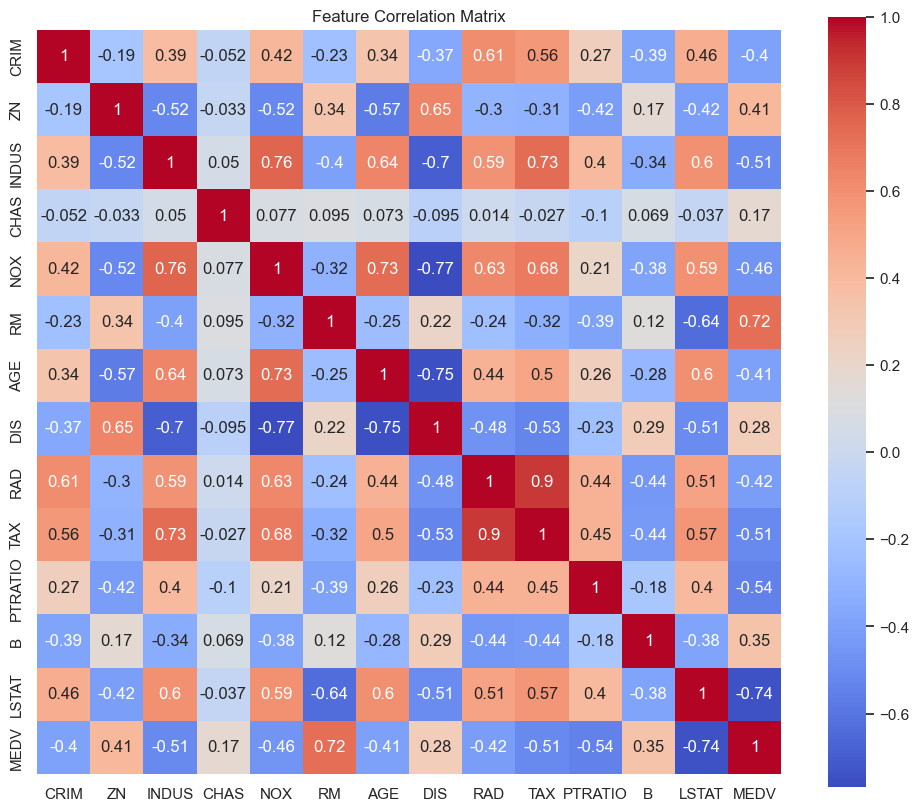

LSTAT     -0.743450
RM         0.723951
PTRATIO   -0.543809
INDUS     -0.510829
TAX       -0.508864
NOX       -0.459054
RAD       -0.416638
AGE       -0.407470
ZN         0.406822
CRIM      -0.397230
B          0.347256
DIS        0.279547
CHAS       0.173701
Name: MEDV, dtype: float64


In [374]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', square=True)  # I used a heatmap to sort correlation with respect to MEDV
plt.title('Feature Correlation Matrix')
plt.show()

# I extracted correlations of all features with respect to 'MEDV' (the target variable), but excluding 'MEDV' itself, and sort them by absolute correlation value in descending order
target_corr = correlation_matrix["MEDV"].drop("MEDV").sort_values(key=abs, ascending=False)
print(target_corr)

In [375]:
high_corr_features = target_corr[abs(target_corr) > 0.8].index.tolist()
df_high = df[high_corr_features + ['MEDV']]

# I selected features from the correlation with the target ('MEDV') that have a strong correlation (absolute value > 0.8), this returns their column names as a list

In [376]:
mid_corr_features = target_corr[(abs(target_corr) >= 0.5) & (abs(target_corr) < 0.8)].index.tolist()
df_mid = df[mid_corr_features + ['MEDV']]

# I selected features that have a 'moderate correlation' / 'mid' / medium with the target ('MEDV')
# Those are correlation values between 0.5 and 0.8 (absolute value)

In [377]:
# I separated the full dataset into features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Afterwards split the full dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then I repeated the separation for the dataset with only moderately correlated features
X_mid = df_mid.drop('MEDV', axis=1)
y_mid = df_mid['MEDV']

# And split the mid-correlation dataset into training and testing sets
X_mid_train, X_mid_test, y_mid_train, y_mid_test = train_test_split(X_mid, y_mid, test_size=0.2, random_state=42)

In [378]:
model_full = LinearRegression() # I created a linear regression model using all features
model_full.fit(X_train, y_train) # Fit the model on the training data
y_pred_full = model_full.predict(X_test) # Predicted the target values for the test set
print("Full Feature R2 Score:", model_full.score(X_test, y_test)) # And this one prints the R² score (coefficient of determination)

Full Feature R2 Score: 0.627084994167318


In [379]:
# This one is the same but for moderately correlated features
model_mid = LinearRegression()
model_mid.fit(X_mid_train, y_mid_train)
y_pred_mid = model_mid.predict(X_mid_test)
print("Mid Correlation R2 Score:", model_mid.score(X_mid_test, y_mid_test))

Mid Correlation R2 Score: 0.5410060548184238


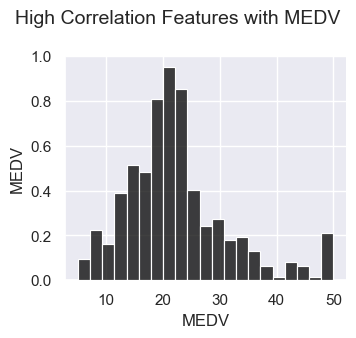

In [380]:
sns.set(style="darkgrid")
sns.pairplot(df[high_corr_features + ['MEDV']], plot_kws={'color': 'black'}, diag_kws={'color': 'black'}, height=3, aspect=1.2)
plt.suptitle("High Correlation Features with MEDV", fontsize=14, y=1.1)
plt.show()

# Before adding some style by using seaborn, the code was:
#sns.pairplot(df[high_corr_features + ['MEDV']])
#plt.show()

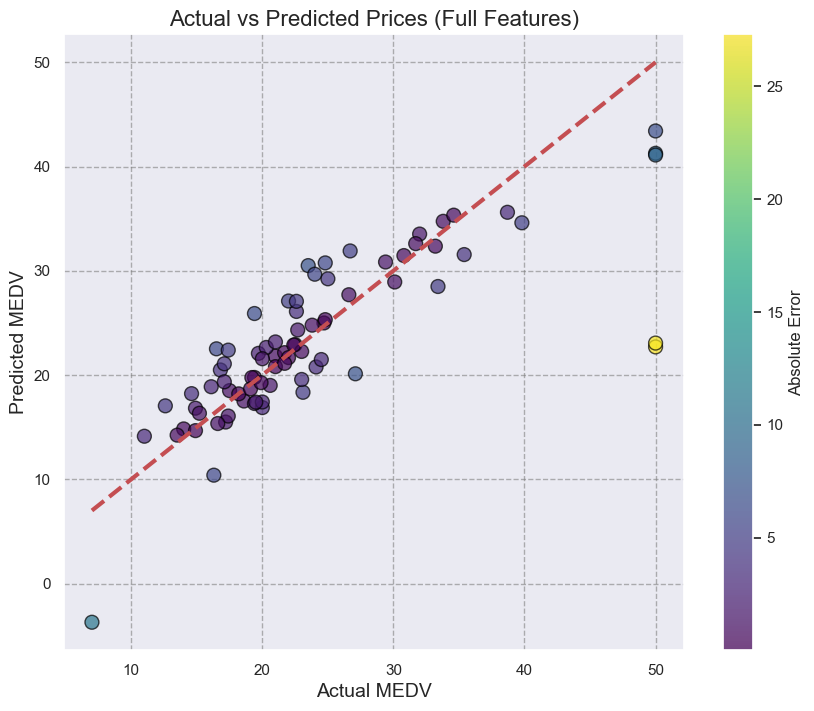

In [381]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(y_test, y_pred_full, c=np.abs(y_test - y_pred_full), cmap='viridis', alpha=0.7, s=100, edgecolor='black') # I found out you can use gradient for dots :O

plt.colorbar(scatter, label='Absolute Error') # I found out how to add a color bar

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=3) #I found out that r-- and red have a difference lol: dashed red line and a simple red line
plt.xlabel("Actual MEDV", fontsize=14)
plt.ylabel("Predicted MEDV", fontsize=14)
plt.title("Actual vs Predicted Prices (Full Features)", fontsize=16)

# I made the grid lighter and less intrusive
plt.grid(True, linestyle='--', color='gray', alpha=0.6)
plt.show()


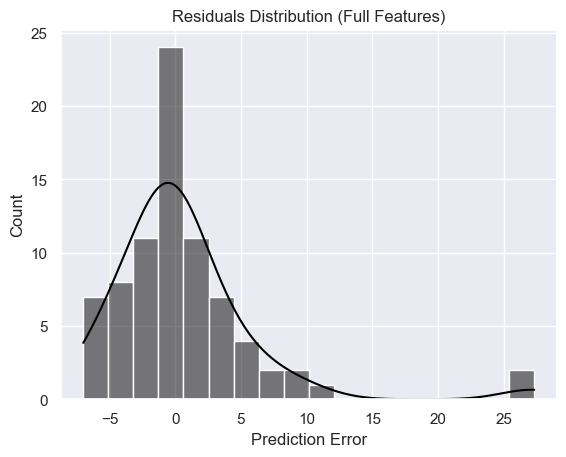

In [382]:
residuals = y_test - y_pred_full
sns.histplot(residuals, kde=True, color = 'black') # I liked it simply black lol
plt.title("Residuals Distribution (Full Features)")
plt.xlabel("Prediction Error")
plt.show()

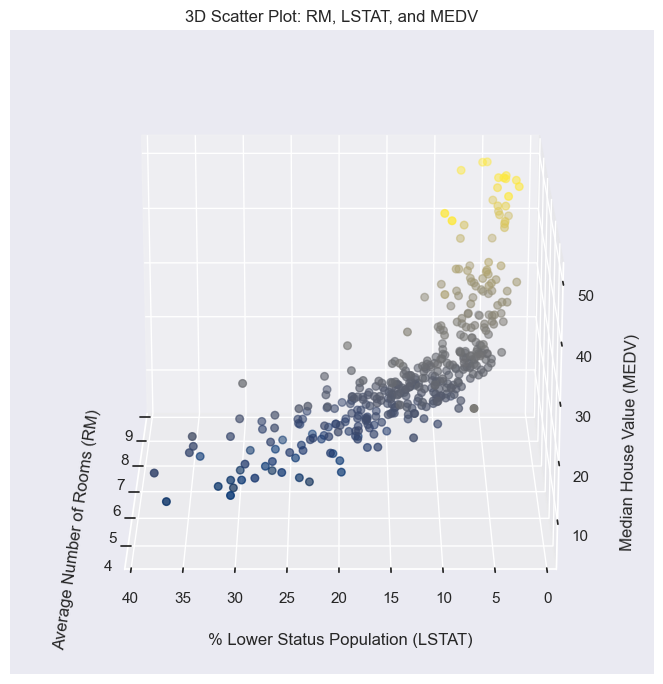

In [383]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['RM'], df['LSTAT'], df['MEDV'], c=df['MEDV'], cmap='cividis', s=30)
ax.set_xlabel('Average Number of Rooms (RM)', labelpad=15)
ax.set_ylabel('% Lower Status Population (LSTAT)', labelpad=15)
ax.set_zlabel('Median House Value (MEDV)', labelpad=15)
ax.view_init(elev=20, azim=180)  # I found out you can 'rotate' plots for a better angle (only if 3d), the set_zlabel was not visible that's why I added this option lol
ax.set_title('3D Scatter Plot: RM, LSTAT, and MEDV')
plt.tight_layout()
plt.show()

In [384]:
# So, looking at the features with high correlation to MEDV (house prices), we can make some business sense of it.
# 'RM' (average number of rooms) has a strong positive correlation with MEDV.
# More rooms usually mean a bigger or more luxurious house, which naturally costs more.
# 'LSTAT' (percentage of lower status population) has a strong negative correlation.
# In general, houses in areas with more poverty tend to be cheaper, likely due to lower demand.
# 'PTRATIO' (student-teacher ratio) also matters.
# A lower ratio often means better schools, which makes a neighborhood more attractive to families, raising house values.
# These features help explain what really affects house prices — like size, location quality, access to good education or other aspects I didn't mention.